<a href="https://colab.research.google.com/github/yewonhn/My-AI-Lab/blob/main/5%EC%A3%BC%EC%B0%A8/05_breast_CL_RE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/breast_cancer.csv")

df

,Unnamed: 0,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,label
0,0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,...,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890,0
1,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,...,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902,0
2,2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,...,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758,0
3,3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,...,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300,0
4,4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,...,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,0
565,565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,0
566,566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,0
567,567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,0


### 분류
암 여부 판별 - 이진분류

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df.drop(['Unnamed: 0', 'label'], axis=1)
y = df['label']

# 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 스케일링
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [4]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense

model_cancer = Sequential([
    Input(shape=(30,)), # 입력 특징이 30개
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid') # 이진분류! 시그모이드 함수!
])

model_cancer.compile(
    optimizer='adam',
    loss='binary_crossentropy', # 이진 분류 전용 손실함수
    metrics=['accuracy']
)

In [5]:
# 학습 시작 (X_train_scaled를 넣는 것 잊지 말기..)
model_cancer.fit(X_train_scaled, y_train, epochs=100, validation_split=0.2)

# 평가
loss, acc = model_cancer.evaluate(X_test_scaled, y_test)
print(f"암 진단 정확도: {acc:.4f}")

Epoch 1/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - accuracy: 0.6731 - loss: 0.6033 - val_accuracy: 0.9011 - val_loss: 0.4238
Epoch 2/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9505 - loss: 0.3451 - val_accuracy: 0.9670 - val_loss: 0.2710
Epoch 3/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9560 - loss: 0.2238 - val_accuracy: 0.9451 - val_loss: 0.1955
Epoch 4/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9670 - loss: 0.1586 - val_accuracy: 0.9560 - val_loss: 0.1568
Epoch 5/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9725 - loss: 0.1240 - val_accuracy: 0.9670 - val_loss: 0.1362
Epoch 6/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9808 - loss: 0.1019 - val_accuracy: 0.9670 - val_loss: 0.1238
Epoch 7/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9808 - loss: 0.0875 - val_accuracy: 0.9670 - val_loss: 0.1157
Epoch 8/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9863 - loss: 0.0772 - val_accuracy: 0.

###회귀
전체 면적(mean area)를 예측하는 모델

In [10]:
y_reg = df['mean area']
X_reg = df.drop('mean area', axis=1)

X_train, X_test, y_train, y_test = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [12]:
model_cancer_reg = Sequential([
    Input(shape=(X_train_scaled.shape[1],)),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(1)
])

model_cancer_reg.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

history = model_cancer_reg.fit(X_train_scaled, y_train, epochs=200, validation_split=0.2, verbose=0)

In [13]:
loss,mae = model_cancer_reg.evaluate(X_test_scaled, y_test)
print(f"MAE(평균 오차) : {mae:.4f}")

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 754.7053 - mae: 19.0491
MAE(평균 오차) : 19.0491


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


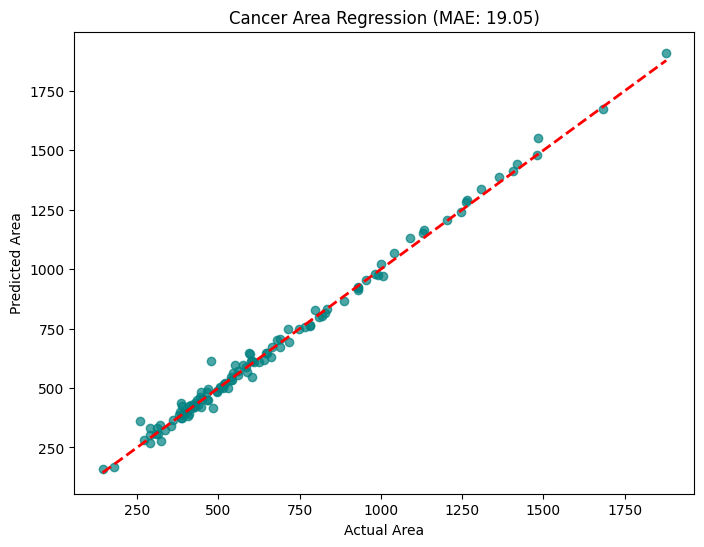

In [15]:
import matplotlib.pyplot as plt

# 예측값 생성
y_pred = model_cancer_reg.predict(X_test_scaled)

plt.figure(figsize=(8, 6))
# 실제값 vs 예측값
plt.scatter(y_test, y_pred, alpha=0.7, color='teal')
# 기준이 되는 대각선
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)

plt.xlabel('Actual Area')
plt.ylabel('Predicted Area')
plt.title(f'Cancer Area Regression (MAE: {mae:.2f})')
plt.show()